# 주식 데이터를 로드해 주가 캔들차트로 시각화 하기
- **FinanceDataReader(FDR)**: 각종 금융 데이터 수집을 지원하는 라이브러리
- `깃허브`: https://financedata.github.io/
- **MplFinance**: 재무 데이터의 시각화 및 분석을 지원하는 라이브러리
- `깃허브`: https://github.com/matplotlib/mplfinance
  - 주식 차트에 맞는 캔들형 차트를 활용
  - 캔들 차트에는 시가(주식장 시작시 가격), 고가(일일 최고 가격), 저가(일일 최저 가격), 종가(주식장 마감시 가격)를 일봉 캔들 한개씩으로 표현함
  - 종가 > 시가이면 빨간색으로 양봉 캔들 생성, 종가 < 시가이면 파란색으로 음봉 캔들 생성
  - 시간(날)에 따른 가격으로 차트를 표현 

In [1]:
!pip install finance-datareader

In [7]:
!pip install mplfinance

In [9]:
import FinanceDataReader as fdr
print(fdr.__version__)

0.9.102


In [73]:
# 코스피 상장 주식 정보 출력
df = fdr.StockListing('KOSPI')
df

# Code: 국내 코스피 주식 종목 코드
# Close:종가, Open:시가, High:고가, Low:저가
# Volumn: 주식 거래량
# Amount: 거래대금
# Marcap: 시가 총액

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
0,005930,KR7005930003,삼성전자,KOSPI,,161400,1,11000,7.31,157900,161600,157200,19629244,3133196972300,955429560610800,5919637922,STK
1,000660,KR7000660001,SK하이닉스,KOSPI,,896000,1,66000,7.95,874000,902000,871000,3294619,2925047146000,652290119040000,728002365,STK
2,005380,KR7005380001,현대차,KOSPI,,491000,1,13000,2.72,487000,494500,473000,1667072,807634937000,100536063106000,204757766,STK
3,005935,KR7005931001,삼성전자우,KOSPI,,116950,1,6850,6.22,114500,117400,114300,1736598,200916887100,95428236954800,815974664,STK
4,373220,KR7373220003,LG에너지솔루션,KOSPI,,387500,1,7500,1.97,391000,391000,381500,152264,58962007750,90675000000000,234000000,STK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,001525,KR7001521004,동양우,KOSPI,,4895,1,140,2.94,4820,4945,4820,14811,72875505,3023793245,617731,STK
947,001527,KR7001522002,동양2우B,KOSPI,,9390,1,390,4.33,9100,9490,9100,9775,89461500,2897462910,308569,STK
948,014915,KR7014911002,성문전자우,KOSPI,,4690,1,30,0.64,4680,4740,4680,1387,6516400,2814000000,600000,STK
949,004415,KR7004411005,서울식품우,KOSPI,,1222,1,20,1.66,1202,1223,1202,238,290646,2718339000,2224500,STK


In [15]:
# 미국 나스닥 상장 주식 정보
fdr.StockListing('NASDAQ')

100%|█████████████████████████████████████████████████████████████████████████████| 3809/3809 [00:06<00:00, 620.97it/s]


,Symbol,Name,IndustryCode,Industry
0,NVDA,NVIDIA Corp,57101010,반도체
1,AAPL,Apple Inc,57106020,전화 및 소형 장치
2,MSFT,Microsoft Corp,57201020,소프트웨어
3,AMZN,Amazon.com Inc,53402010,백화점
4,GOOGL,Alphabet Inc Class A,57201030,온라인 서비스
...,...,...,...,...
3804,NEWTO,Newtekone 8 50 Fixed Rate Senior Notes Due 2031,55101050,기업 금융 서비스
3805,BLRK,Bluerock Acquisition Corp,55601010,투자 지주 회사
3806,FITBM,Fifth Third Bancorp Depositary Shares Represen...,55101010,은행
3807,PLYX,Polaryx Therapeutics Inc,56202010,생명 공학 및 의학 연구


In [17]:
# 상장 주식 코드 및 티커 심볼 확인 사용자 정의 함수
def getStockCode(market='KOSPI', sort='Marcap'):
    df = fdr.StockListing(market)   # DF 가져오기
    if market == 'KOSPI':
        df.sort_values(by=sort, ascending=False, inplace=True) # 변수명에 바로 반영
        return df[['Code', 'Name', 'Marcap']]
    elif market == 'NASDAQ':
        return df[['Symbol', 'Name']]

In [20]:
getStockCode('NASDAQ', 'Name')

100%|█████████████████████████████████████████████████████████████████████████████| 3809/3809 [00:06<00:00, 627.67it/s]


,Symbol,Name
0,NVDA,NVIDIA Corp
1,AAPL,Apple Inc
2,MSFT,Microsoft Corp
3,AMZN,Amazon.com Inc
4,GOOGL,Alphabet Inc Class A
...,...,...
3804,NEWTO,Newtekone 8 50 Fixed Rate Senior Notes Due 2031
3805,BLRK,Bluerock Acquisition Corp
3806,FITBM,Fifth Third Bancorp Depositary Shares Represen...
3807,PLYX,Polaryx Therapeutics Inc


## 종목별 주식 데이터 파악

In [24]:
# 지난 1년간 코스피 지수 확인
    # DataReader: 특정 주식의 기간에 따른 가격, 거래량 등의 데이터를  DF로 출력
    # 지수 코드는 fdr 사이트에서 확인 가능
fdr.DataReader('KS11', '2025-02-02', '2026-02-02')  # 지수코드, 시작일, 종료일 (종료일 안 쓰면 오늘까지 나옴!!)

,Open,High,Low,Close,Volume,Change,UpDown,Comp,Amount,MarCap
Date,,,,,,,,,,
2025-02-03,2468.74,2468.74,2437.61,2453.95,522848036,-0.0252,2,-63.42,11649962821524,2005228762346525
2025-02-04,2481.44,2508.35,2471.63,2481.69,479377343,0.0113,1,27.74,11000937680837,2028588344752300
2025-02-05,2503.94,2514.71,2498.74,2509.27,437344153,0.0111,1,27.58,9949594557748,2056473640972619
2025-02-06,2521.82,2536.75,2515.34,2536.75,479697230,0.0110,1,27.48,11863047995673,2078576667689643
2025-02-07,2532.09,2537.63,2519.01,2521.92,419872051,-0.0058,2,-14.83,10240140504999,2066649815662131
...,...,...,...,...,...,...,...,...,...,...
2026-01-27,4932.89,5084.85,4890.72,5084.85,476155582,0.0273,1,135.26,28496381114727,4203734778009835
2026-01-28,5145.39,5183.44,5124.80,5170.81,593108778,0.0169,1,85.96,30856467311072,4276044578125425
2026-01-29,5243.42,5252.61,5073.12,5221.25,699659390,0.0098,1,50.44,35870200939592,4315677778298127


In [27]:
# 25년도 나스닥 지수 확인
fdr.DataReader('IXIC', '2025', '2026')   # 지수코드, 시작년도, 끝년도(미포함)

,Open,High,Low,Close,Volume,Adj Close
2024-12-31,19551.359375,19563.720703,19283.410156,19310.789062,8873030000,19310.789062
2025-01-02,19403.900391,19517.869141,19117.589844,19280.789062,8737550000,19280.789062
2025-01-03,19395.509766,19638.660156,19379.570312,19621.679688,8214050000,19621.679688
2025-01-06,19851.990234,20007.949219,19785.000000,19864.980469,9586840000,19864.980469
2025-01-07,19938.080078,19940.210938,19421.019531,19489.679688,13371130000,19489.679688
...,...,...,...,...,...,...
2025-12-24,23555.949219,23621.720703,23527.970703,23613.310547,3885190000,23613.310547
2025-12-26,23645.910156,23665.150391,23567.859375,23593.099609,5170300000,23593.099609
2025-12-29,23414.679688,23531.019531,23397.519531,23474.349609,6527530000,23474.349609
2025-12-30,23465.669922,23521.050781,23414.830078,23419.080078,6769300000,23419.080078


In [29]:
# 삼성전자 종목확인
fdr.DataReader('005930', '2025')  # 시작년도만 설정하면 2025 첫거래일부터 현재날짜까지 출력

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-01-02,52700,53600,52300,53400,16630538,0.003759
2025-01-03,52800,55100,52800,54400,19318046,0.018727
2025-01-06,54400,56200,54300,55900,19034284,0.027574
2025-01-07,56800,57300,55400,55400,17030235,-0.008945
2025-01-08,54800,57500,54700,57300,26593553,0.034296
...,...,...,...,...,...,...
2026-01-28,162600,163300,160200,162400,29456431,0.018182
2026-01-29,166200,166600,157100,160700,36087223,-0.010468
2026-01-30,160100,166500,160100,160500,40557267,-0.001245


In [48]:
# datetime: 날짜와 시간을 다루는 모듈
from datetime import datetime, timedelta

# 기간에 따라 종목 데이터를 읽어오는 사용자 정의 함수
def getData(code, dataStart, dateEnd):
    df = fdr.DataReader(code, dataStart, dateEnd)
    return df

code = '005930'
# today().date(): 오늘 날짜의 년월일 출력
date_end = datetime.today().date()

# timedelta: 두 날짜, 시간 간의 차이를 출력
# 매개변수는 weeks, days, hours, minutes, seconds
date_start = date_end - timedelta(days=720)

df = getData(code, date_start, date_end)
df

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2024-02-14,73700,74300,73700,74000,12434945,-0.015957
2024-02-15,74200,74400,73000,73000,14120600,-0.013514
2024-02-16,73300,73400,72500,72800,13444781,-0.002740
2024-02-19,72800,73900,72800,73800,12726404,0.013736
2024-02-20,73700,73700,72800,73300,14681477,-0.006775
...,...,...,...,...,...,...
2026-01-28,162600,163300,160200,162400,29456431,0.018182
2026-01-29,166200,166600,157100,160700,36087223,-0.010468
2026-01-30,160100,166500,160100,160500,40557267,-0.001245


In [38]:
datetime.today().date()

datetime.date(2026, 2, 3)

<Axes: xlabel='Date'>

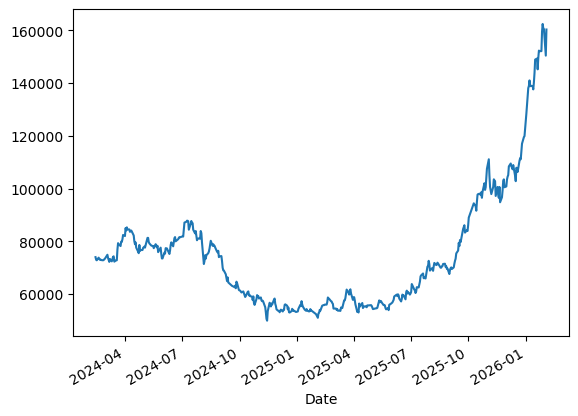

In [49]:
# pandas 지원 시각화 기능 사용!
df['Close'].plot()

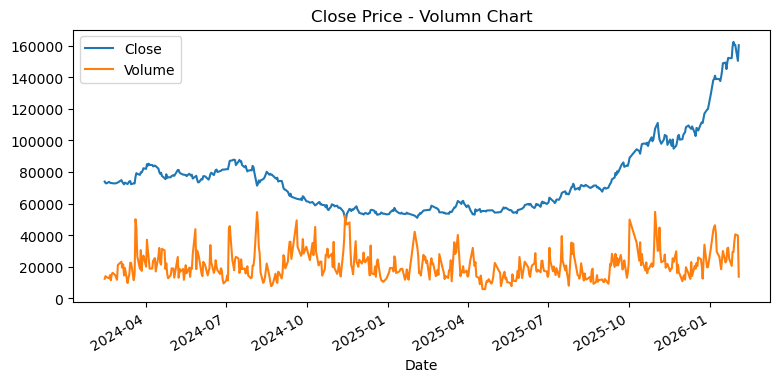

In [54]:
# 시간에 따른 종가 - 거래량 비교 차트
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
df['Close'].plot()
(df['Volume']/1000).plot()       # 1000으로 나눠서 보기 좋은 비율로 변환  
plt.title('Close Price - Volumn Chart')
plt.legend()
plt.show()

## 캔들 차트 만들기

<class 'matplotlib.figure.Figure'>
Figure(1200x700)
===
<class 'list'>
[<Axes: ylabel='Price'>, <Axes: >, <Axes: ylabel='Volume  $10^{6}$'>, <Axes: >]


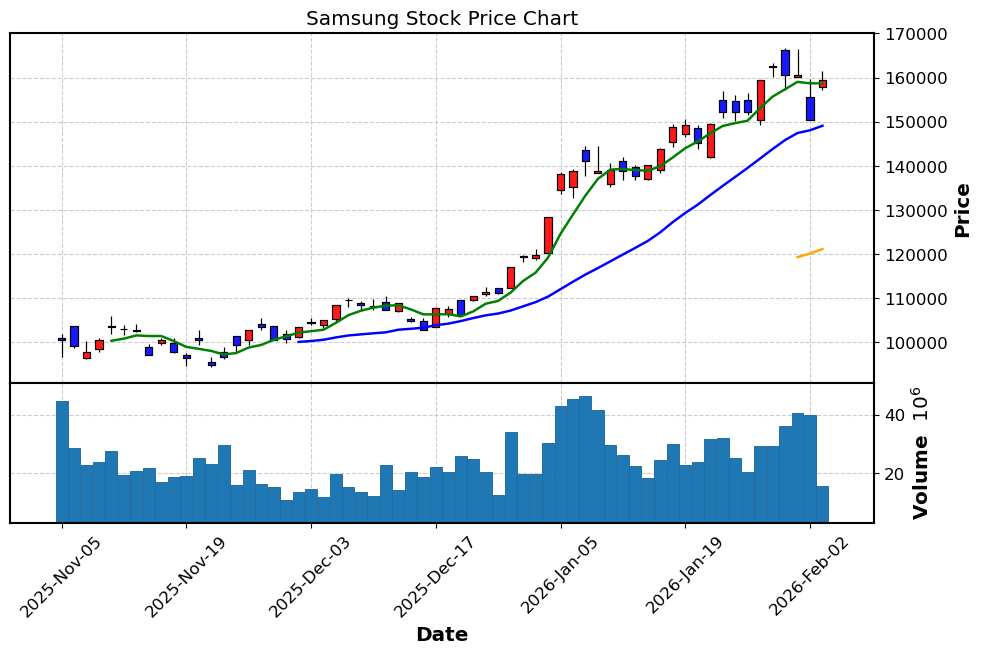

In [68]:
import FinanceDataReader as fdr
import mplfinance as mpf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

def getData(code, dataStart, dateEnd):
    df = fdr.DataReader(code, dataStart, dateEnd)
    return df

code = '005930'
date_end = datetime.today().date()
date_start = date_end - timedelta(days=90)

df = getData(code, date_start, date_end)

# ========== 차트 생성을 위한 값 설정 파트 ===========

# 차트 테마
# 'default', 'binance', 'classic'
chart_style = 'classic'

# 차트 요소 세부 색상 지정
# up:양봉, down:음봉
marketcolors = mpf.make_marketcolors(up='red', down='blue')

# 차트 요소 스타일 설정
mpf_style = mpf.make_mpf_style(
    base_mpf_style=chart_style,   # 설정한 차트 스타일 입력
    marketcolors=marketcolors     # 설정한 색상 입력
)

# 차트 생성
fig, ax = mpf.plot(
    data=df,                  # 데이터 입력
    type='candle',
    style=mpf_style,         # 스타일 객체 입력
    figsize=(12, 7),
    fontscale=1.0,            # 폰트 상대크기 설정
    mav=(5, 20, 60),          # 이동평균선(Moving Average): 5일선(1주), 20일선(1달), 60일선(3달)
    mavcolors=('green', 'blue', 'orange'),  # mav별 색상
    returnfig=True,           # fig 및 ax 객체 분리
    volume=True              # 거래량 차트 출력 여부
)

print(type(fig))
print(fig)
print('===')
print(type(ax))
print(ax)

ax[0].set_title('Samsung Stock Price Chart')
ax[2].set_xlabel('Date')
plt.show()

In [57]:
# 차트 테마 목록 확인!
mpf.available_styles()

['binance',
 'binancedark',
 'blueskies',
 'brasil',
 'charles',
 'checkers',
 'classic',
 'default',
 'ibd',
 'kenan',
 'mike',
 'nightclouds',
 'sas',
 'starsandstripes',
 'tradingview',
 'yahoo']

## **Streamlit으로 웹상에 대화형 주가 차트 출력**
- 원하는 정보를 다 입력하고 그래프에 적용되도록 sidebar 활용
- 세션을 활용하여 sidebar에서 입력받은 설정을 페이지 전반에 유지
- 캐시는외부 정보를 받아오는 함수들에 적용

In [91]:
%%writefile module/myApp27.py

import streamlit as st
import FinanceDataReader as fdr
import mplfinance as mpf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

st.subheader('국내 주가 데이터 시각화')

# ======================= 함수 선언부 =========================

# 외부에서 가져오기 때문에 '캐시데이터 설정!!!!!!' 해서 효율적으로 메모리 사용

# 종목 코드 및 기간 설정에 따른 DF 반환 함수
@st.cache_data
def getData(code, dataStart, dateEnd):
    df = fdr.DataReader(code, dataStart, dateEnd)
    return df

# 시가총액 기준으로 종목코드, 회사명 DF 반환 함수
@st.cache_data
def getStockCode(market='KOSPI', sort='Marcap'):
    df = fdr.StockListing(market)   # DF 가져오기
    df.sort_values(by=sort, ascending=False, inplace=True) # 변수명에 바로 반영
    return df[['Code', 'Name']]

# ==============================================================

# ======================= 세션 설정부 =========================

# 종목코드 변경시 목록의 index로 활용될 code_index 키 설정
if 'code_index' not in st.session_state:
    st.session_state['code_index'] = 0

# 기간 설정시 활용될 ndays 키 설정
if 'ndays' not in st.session_state:
    st.session_state['ndays'] = 120

# 차트 스타일 변경시 활용될 'chart_style'키 설정
if 'chart_style' not in st.session_state:
    st.session_state['chart_style'] = 'default'

# 거래량 출력 여부 설정시 활용될 'volume' 키 설정
if 'volume' not in st.session_state:
    st.session_state['volume'] = True

# ===========================================================

# ======================= 사이드바 설정부 =========================

# 사이드바에서 여러 요소들을 입력받아 메인의 차트를 출력할 수 있도록 폼 활용

with st.sidebar.form(key='form1', clear_on_submit=True):
    st.header('🔠 입력값 설정')

    # <종목 선택을 위한 selectbox 만들기>
    # 종목코드와 회사명을 1:1로 매핑시켜서 출력
    choices_tuple = zip(getStockCode()['Code'], getStockCode()['Name'])
    # 보기 좋게 종목코드와 회사명을 ':'로 이어서 한문자열로 리스트에 담기
    choices_list = [' : '.join(i) for i in choices_tuple]  # 만약 값이 숫자면, map으로 감싸서 str로 바꿔서 join 하기~ ':'.join(map(str, i))

    # 매개변수 index : 선택박스의 초기값을 인덱스로 지정(처음에는 세션에 있는 0이 들어가있음) 
    choice = st.selectbox('종목', choices_list, index=st.session_state['code_index'])
    # index 함수: 리스트 내 특정값의 index를 반환 (세션에 반영할 예정)
    code_index = choices_list.index(choice)
    # 종목 코드만 추출 (메인부에서 활용할 예정)
    code = choice.split(' : ')[0]
    
    # # 확인용~~~~~
    # st.write(choice)
    # st.write(code_index)
    # st.write(code)
    ''

    # <기간 설정 슬라이더 만들기>
    ndays = st.slider('기간 (days): ', min_value=5, max_value=730,
                     value=st.session_state['ndays'], step=1)
    ''

    # <차트 테마 목록 선택박스 만들기>
    chart_style_list = ['binance', 'binancedark', 'blueskies', 'brasil', 'charles',
    'checkers', 'classic', 'default', 'ibd', 'kenan', 'mike', 'nightclouds', 'sas', 
    'starsandstripes', 'tradingview', 'yahoo']
    # index에는 default의 인덱스 번호인 7번 입력 
    chart_style = st.selectbox('차트 스타일: ', chart_style_list, index=7)
    ''

    # <거래량 설정 체크박스 만들기>
    # value=True : 기본으로 체크에 표시되어 있는 상태
    volume = st.checkbox('거래량', value=True)

    # 폼 제출 버튼을 누르면, 세션에 입력값을 업데이트 하고 rerun
    if st.form_submit_button('입력'):
        st.session_state['code_index'] = code_index
        st.session_state['ndays'] = ndays
        st.session_state['chart_style'] = chart_style
        st.session_state['volume'] = volume
        st.rerun()
        

# ======================================================================

# =========================== 메인화면 설정부 ================================

# 차트 생성 함수 선언
def plotChart(data):
    # 1) 스타일 설정
    chart_style = st.session_state['chart_style']
    marketcolors = mpf.make_marketcolors(up='red', down='blue')
    mpf_style = mpf.make_mpf_style(
        base_mpf_style = chart_style,
        marketcolors = marketcolors
    )
    # 2) 차트 그리기
    fig, ax = mpf.plot(
    data=data,        
    type='candle',
    style=mpf_style,     # 세션 활용
    figsize=(12, 7),
    fontscale=1.0,         
    mav=(5, 20, 60),       
    mavcolors=('green', 'blue', 'orange'),  
    returnfig=True,    
    volume=st.session_state['volume'] # 세션으로 관리 중~~
    )
    return st.pyplot(fig)

# 코스피 종목들 기간 설정 후 getData 실행해서 DF로 반환
date_end = datetime.today().date()
date_start = date_end - timedelta(days=st.session_state['ndays'])
df = getData(code, date_start, date_end) # 사이드바에서 추출한 code 변수 입력

# 현재 저장되어있는 code_index값으로 choices_list에 있는 기업명만 추출하여
# 메인 화면에 종목 타이틀로 지정
# [9:] 앞의 종목코드(6자리)와 ' : '를 빼고 기업명만 슬라이싱
chart_title = choices_list[st.session_state['code_index']][9:]
st.write('현재 차트➡️', chart_title)
st.write('**이동평균선(mav)**: :green[5일], :blue[20일], :orange[60일]')

plotChart(df)

Overwriting module/myApp27.py


# 네이버 검색 API를 활용하여 뉴스 크롤링하고, 본문 텍스트를 워드 클라우드로 시각화
### 네이버 검색 API 활용
- **API(Application Programming Interface)**: 두 소프트웨어(사용자, 제공자)가 서로 통신할 수 있게 해주는 메커니즘과 해당 기능을 사용할 수 있게 하는 프로그램
- library는 특정 기능을 구현하기 위한 코드의 집합인데 반해, API는 통신이 가능한 상황에서 간단한 명령 코드로 필요한 기능들을 더쉽게 구현할 수 있음 (단 API는 보통 비용을 수반함) 

## 네이버 검색 API 호출 및 검색 결과 확인

In [104]:
import json
import requests as req

client_id = '3tGkT_GCN3ehL4ASdA_p'
client_secret = 'IQXiIrA66h'

keyword = '핀테크'
display_amount = 100
start_position = 1

# GET 방식의 url에 쿼리스트링 형식(url 뒤쪽에 ?를 붙이고 &로 주소를 이어줌)으로 원하는 파라미터값들 넣기
    # query: 검색어 (필수)
    # display: 한번에 표시할 검색 결과 개수 (기본값10, 최대100)
    # start: 검색 시작 위치 (기본값1, 최대값1000)
    # 즉 display와 start를 최대값으로 설정하면 최대 1100개까지 검색이 가능
url = f'https://openapi.naver.com/v1/search/news.json?query={keyword}&display={display_amount}&start={start_position}'

# 네이버 API에 접속을 위해 id, secret 설정
N_A = {'X-Naver-Client-Id': client_id, 'X-Naver-Client-Secret': client_secret}

res = req.get(url, headers=N_A) # 통신 요청
my_json = json.loads(res.text) # json 형식으로 파싱
# print(my_json)

print('my_json 자료형: ', type(my_json))
print('my_json key 종류: ', my_json.keys())
print('my_json items 개수: ', len(my_json['items']))
print('첫번째 뉴스 key 종류: ', my_json['items'][0].keys())
print()

# 검색 결과에 대한 items 값 출력
cnt = 1
for i in my_json['items']:
    # 네이버 뉴스만 검색
    if 'n.news.naver' in i.get('link'):
        print('Count:', str(cnt))
        print('Title:', i.get('title'))
        print('Link:', i.get('link'))
        print('Description:', i.get('description'))
        print()
        cnt += 1




my_json 자료형:  <class 'dict'>
my_json key 종류:  dict_keys(['lastBuildDate', 'total', 'start', 'display', 'items'])
my_json items 개수:  100
첫번째 뉴스 key 종류:  dict_keys(['title', 'originallink', 'link', 'description', 'pubDate'])

Count: 1
Title: [기자수첩]케이뱅크 IPO 풀리지 않는 의문
Link: https://n.news.naver.com/mnews/article/031/0001002500?sid=110
Description: 일본 최대 이커머스·<b>핀테크</b> 그룹인 라쿠텐그룹의 플랫폼 생태계 한가운데에 있다. 결제와 포인트, 이커머스가 얽힌 구조 속에서 고객을 묶어두는 방식이 은행 실적을 넘어선 성장 기대를 만들어 왔다. 라쿠텐은행의... 

Count: 2
Title: 스테이블코인 이자 허용?…월가 vs 코인업계 격돌
Link: https://n.news.naver.com/mnews/article/001/0015882485?sid=104
Description: 유럽연합(EU)의 <b>핀테크</b> 전문가 그룹 의장을 역임한 필립 패치 영국 런던정경대(LSE) 교수는 FT와의 인터뷰에서 &quot;전체 금융 시스템의 유동성이 줄면 대출 비용이 인상될 수밖에 없다&quot;며 &quot;우리는 여전히 전통 금융 시스템의... 

Count: 3
Title: 헥토파이낸셜, 서클표 스테이블코인 결제망 인프라 구축
Link: https://n.news.naver.com/mnews/article/092/0002408975?sid=105
Description: CPN은 금융기관, 지급결제 서비스 제공자(PSP), <b>핀테크</b> 기업을 연결해 USDC, EURC 등의 스테이블코인을 이용한 자동화된 상시 정산을 지원한다. CPN은 중개기관 없이 기존 결제 시스템과 블록체인 기반

## 워드 클라우드 생성
- 텍스트 데이터에서 자주 등장하는 단어를 더 크게 표시하여 핵심 키워드를 한 눈에 파악할 수 있도록 하는 시각화 기법

In [106]:
!pip install -q wordcloud

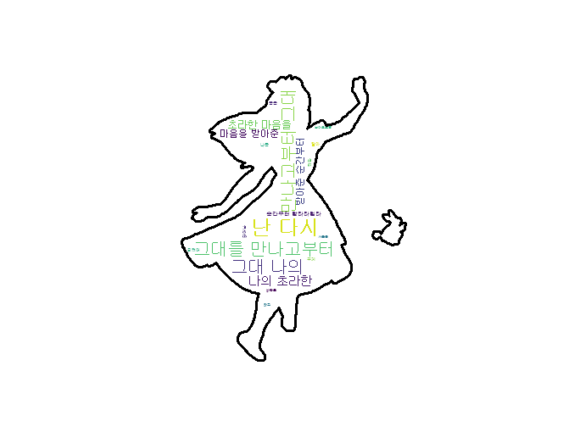

In [115]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 이미지를 배열로 로드
alice_mask = np.array(Image.open('data/alice_mask.png'))

# 워드클라우드 객체 생성
wc = WordCloud(
    font_path=r'C:\Windows\Fonts\Gulim.ttc', # 한글 글꼴 경로 (mac은 서체관리자에서 확인)
    background_color='white',
    max_words=20,                   # 표시할 최대 단어 개수
    random_state=99,                 # 출력위치 고정 랜덤 시드값
    stopwords=['있다', '및', '수', '이', '다'],   # 제외하고 싶은 단어 설정 (불용어 설정)
    
    mask=alice_mask,         # 마스크 배경 이미지 설정
    contour_color='black',   # 배경 이미지 테두리 색상
    contour_width=3          # 배경 이미지 테두리 두께
)

text='''
바람을 타고 날아오르는
새들은 걱정 없이
아름다운 태양 속으로
음표가 되어 나네
향기 나는 연필로 쓴 일기처럼
숨겨두었던 마음
기댈 수 있는 어깨가 있어
비가 와도 젖지 않아
어제의 일들은 잊어
누구나 조금씩은 틀려
완벽한 사람은 없어
실수투성이고 외로운 나를 봐
난 다시 태어난 것만 같아
그대를 만나고부터
그대 나의 초라한 마음을
받아준 순간부터 랄라라릴라 (랄라라릴라)
하루하루 조금씩 나아질 거야
그대가 지켜보니
힘을 내야지 행복해져야지
뒤뜰에 핀 꽃들처럼
점심을 함께 먹어야지
새로 연 그 가게에서
새 샴푸를 사러 가야지
아침 하늘빛의 민트향이면 어떨까?
난 다시 꿈을 꾸게 되었어
그대를 만나고부터
그대 나의 초라한 마음을
'''

# generate: 문자열에서 단어의 빈도(띄어쓰기 기준)를 자동 계산하여 워드클라우드 생성
wc.generate(text)
fig = plt.figure(figsize=(7, 7))
# interpolation : 보간법 (이미 알려진 값 사이의 알려지지 않은 값을 추정하는 기법)
    # bilinear: 이중선형보간법 (x,y축이 있는 좌표에 보간법 적용)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off') # x,y 축의 tick값들 안 보이게 설정
plt.show()

## Streamlit으로 크롤링한 뉴스 기사 워드클라우드 시각화

In [1]:
%%writefile module/myApp28.py
import streamlit as st
import json
import requests
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from PIL import Image
from bs4 import BeautifulSoup as bs


# ========================= 함수 선언부 ==========================
# 네이버 뉴스 검색 결과를 반환하는 함수
def getRequest(keyword, display, start) : # 키워드, 검색량, 시작점
    url = f'https://openapi.naver.com/v1/search/news.json?query={keyword}&display={display}&start={start}'
    N_A = {'X-Naver-Client-Id': st.session_state['client_id'], 
           'X-Naver-Client-Secret': st.session_state['client_secret']}
    res = requests.get(url, headers=N_A) # 통신 요청
    my_json = json.loads(res.text) # json 형식으로 파싱

    return my_json['items']

# 워드클라우드 시각화 함수
# (문자열 텍스트, 배경 이미지, 최대 단어수, empty공간 객체)
def wcChart(corpus, back_mask, max_words, emp) :
    # 배경 이미지 선택
    if back_mask == '타원':
        img = Image.open('data/background_1.png')
    elif back_mask == '말풍선':
        img = Image.open('data/background_2.png')
    elif back_mask == '하트':
        img = Image.open('data/background_3.png')
    else :
        img = Image.open('data/background_0.png')
        
    # 배경 이미지를 배열로 변환
    my_mask = np.array(img)
    
    # 워드 클라우드
    wc = WordCloud(
    font_path=r'C:\Windows\Fonts\Gulim.ttc', 
    background_color='white',
    max_words=max_words,               
    random_state=99,            
    stopwords=['있다', '및', '수', '이', '다', 'the', 'a', 'of', 'to', 'in', 'and'],   
    
    mask=my_mask,       
    contour_color='black',  
    contour_width=3
)
 
    wc.generate(corpus)   # 함수의 매개변수인 corpus 입력
    fig = plt.figure(figsize=(10, 10))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    st.pyplot(fig)
    # 함수의 매개변수인 emp 입력
    emp.info(':orange[**워드클라우드 이미지 생성 완료**]', icon='👍')
# ==============================================================
# ========================= 세션 설정부 ==========================

if 'client_id' not in st.session_state:
    st.session_state['client_id'] = ''

if 'client_secret' not in st.session_state:
    st.session_state['client_secret'] = ''


# ==============================================================
# ======================== 사이드바 부분 =========================

with st.sidebar.form(key='form1', clear_on_submit=False):
    st.header('네이버 API 설정💌')

    client_id = st.text_input('Client ID:', value=st.session_state['client_id'])
    client_secret = st.text_input('Client Secret:', 
                                  type='password',
                                  value=st.session_state['client_secret'])

    if st.form_submit_button(label='Ok'):
        st.session_state['client_id'] = client_id
        st.session_state['client_secret'] = client_secret
        st.write('연결 완료')

# ==============================================================
# ========================== 메인 부분 ==========================

# 진행상황 문구를띄워줄 빈 공간 객체 설정
chart_emp = st.empty()

try :
    with st.form(key='form2', clear_on_submit=False) :
        search_keyword = st.selectbox(
            # 뉴스 대표 카테고리들
            '키워드 :', ['핀테크', '경제', '정치', '국제', '연예', 'IT', '문화']
        )

        data_amount = st.slider(
            '분량(1당 100개) :', min_value=1, max_value=5, value=1, step=1
        )

        back_mask = st.radio(
            '워드클라우드 출력 형태 :', ['기본', '타원', '말풍선', '하트'],
            horizontal=True   # 수평 출력
        )

        if st.form_submit_button('출력') :
            chart_emp.info(':red[데이터 수집 중...]', icon='😉')
            items = []    # 뉴스 기사 정보가 담길 리스트
            corpus = ''   # 수집된 뉴스 본문 문자열이 담길 변수

            # 수집 데이터의 양 설정(입력받은 data_amount만큼 반복하여 빈 리스트에 기사 정보 넣기)
            for i in range(data_amount) : 
                # 기사 정보를 수집하는 getRequest 함수 실행(키워드, 한번에 표시될 양, 시작 시점)
                items.extend(getRequest(search_keyword, 100, 100*i+1))

            for item in items :
                # 뉴스 링크가 네이버 링크라면
                if 'n.news.naver' in item['link'] :
                    # 뉴스 url 저장
                    news_url = item['link']   
                    # 통신 요청
                    res = requests.get(news_url, headers={'User-Agent':'Mozilla'})
                    # BS 파싱
                    soup = bs(res.text, 'lxml')
                    # 뉴스 본문 영역에 접근
                    news_tag = soup.select_one('#dic_area')
                    # 텍스트만 추출하여 빈 문자열에 계속 넣어주기
                    corpus += news_tag.text + '\n'

            st.markdown(f'**수집된 corpus 길이** : {len(corpus)}')

            # 워드클라우드를 출력하기에 충분한 데이터가 확보되었으면 시각화 출력
            if len(corpus) >= 300 :    # 300자 이상일 경우
                chart_emp.info(':red[이미지 생성중...]', icon='✌️')
                # 워드클라우드 생성 함수 실행
                wcChart(corpus, back_mask, 100, chart_emp)
            else :
                chart_emp.error(':red[워드클라우드를 생성하기에 데이터가 충분하지 않습니다.]')
                
except Exception as e :
    st.write(e)
    chart_emp.error('ID와 Secret을 입력해주세요')




# ==============================================================


Overwriting module/myApp28.py


In [ ]:
import sys

import os



# 현재 파일(modules/파일명.py)의 부모 폴더(jobnawa)를 경로에 추가합니다.

current_dir = os.path.dirname(os.path.abspath(__file__))

parent_dir = os.path.dirname(current_dir)

sys.path.append(parent_dir)



import pandas as pd

from wordcloud import WordCloud

import matplotlib.pyplot as plt

from PIL import Image

import numpy as np

import streamlit as st



tech_stacks = [

    "JavaScript",

    "HTML",

    "CSS",

    "SQL",

    "Python",

    "Bash",

    "Shell",

    "TypeScript",

    "Java",

    "C#",

    "C++",

    "PowerShell",

    "C",

    "PHP",

    "Go",

    "Rust",

    "Kotlin",

    "Lua",

    "Assembly",

    "Ruby",

    "Dart",

    "Swift",

    "R",

    "Groovy",

    "Visual Basic (.Net)",

    "VBA",

    "MATLAB",

    "Perl",

    "GDScript",

    "Elixir",

    "Scala",

    "Delphi",

    "Lisp",

    "MicroPython",

    "Zig",

    "Erlang",

    "Fortran",

    "Ada",

    "F#",

    "OCaml",

    "Gleam",

    "Prolog",

    "COBOL",

    "Mojo",

    "PostgreSQL",

    "MySQL",

    "SQLite",

    "Microsoft SQL Server",

    "Redis",

    "MongoDB",

    "MariaDB",

    "Elasticsearch",

    "Oracle",

    "DynamoDB",

    "BigQuery",

    "Supabase",

    "Cloud Firestore",

    "H2",

    "Firebase Realtime Database",

    "Microsoft Access",

    "Cosmos DB",

    "Snowflake",

    "InfluxDB",

    "Databricks SQL",

    "DuckDB",

    "Cassandra",

    "Neo4J",

    "Valkey",

    "Clickhouse",

    "IBM DB2",

    "Amazon Redshift",

    "CockroachDB",

    "Pocketbase",

    "Datomic",

    "Docker",

    "npm",

    "AWS",

    "Pip",

    "Kubernetes",

    "Microsoft Azure",

    "Homebrew",

    "Vite",

    "Google Cloud",

    "Make",

    "Yarn",

    "Cloudflare",

    "NuGet",

    "APT",

    "Webpack",

    "Terraform",

    "Maven",

    "Cargo",

    "Gradle",

    "pnpm",

    "Firebase",

    "Prometheus",

    "Ansible",

    "Podman",

    "Chocolatey",

    "Composer",

    "MSBuild",

    "Digital Ocean",

    "Vercel",

    "Poetry",

    "Datadog",

    "Pacman",

    "Netlify",

    "Bun",

    "Heroku",

    "Ninja",

    "Splunk",

    "New Relic",

    "Railway",

    "IBM Cloud",

    "Yandex Cloud",

    "Node.js",

    "React",

    "jQuery",

    "Next.js",

    "Express",

    "ASP.NET Core",

    "Angular",

    "Vue.js",

    "FastAPI",

    "Spring Boot",

    "Flask",

    "ASP.NET",

    "WordPress",

    "Django",

    "Laravel",

    "AngularJS",

    "Svelte",

    "Blazor",

    "NestJS",

    "Ruby on Rails",

    "Astro",

    "Deno",

    "Symfony",

    "Nuxt.js",

    "Fastify",

    "Axum",

    "Phoenix",

]





# 1. 페이지 설정 (가장 상단에 위치)

st.title("요즘 트렌드인 기술은?")



# py는 import하고, csv파일 데이터 준비

parent_dir = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))

csv_path = os.path.join(parent_dir, "crawlers", "data", "final_data.csv")

df = pd.read_csv(csv_path)





# tech_stacks 리스트와 비교해서 빈도수 계산

counts = {}



for tech in tech_stacks:

    count = df["stacks"].str.contains(tech, regex=False).sum()

    if count > 0:

        counts[tech] = count



st.write(f"추출된 기술 스택 개수: {len(counts)}")  # 0이 나오면 매칭 실패



# 워드 클라우드 객체 생성

mask_path = os.path.join(parent_dir, "crawlers", "data", "arrow-pointer.png")

# mask_path = os.path.join(parent_dir, "crawlers", "data", "icon-laptop.png")

# mask_path = os.path.join(parent_dir, "crawlers", "data", "icon-computer.png")



mask_image = np.array(Image.open(mask_path))

wc = WordCloud(

    # font_path=r"C:\Windows\Fonts\Gulim.ttc",  # 한글 글꼴 경로 (mac은 서체관리자에서 확인)

    background_color="white",

    # colormap="Paired",

    max_words=30,  # 표시할 최대 단어 개수

    # random_state=99,  # 출력위치 고정 랜덤 시드값

    stopwords=["R"],  # 제외하고 싶은 단어 설정 (불용어 설정)

    contour_color="black",  # 배경 이미지 테두리 색상

    contour_width=3,  # 배경 이미지 테두리 두께

    width=800,

    height=400,

    mask=mask_image,

    colormap="viridis",

)

if counts:

    wc.generate_from_frequencies(counts)



    # [수정 2] Streamlit 전용 출력 방식 사용

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.imshow(wc, interpolation="bilinear")

    ax.axis("off")

    st.pyplot(fig)  # 웹 화면에 그리기

    plt.close(fig)

else:

    st.warning("매칭된 데이터가 없네요!")

